In [2]:
from PIL import Image, ImageOps


def collage(imgs, n, m, w, h, out_path=None, bg_color=(255, 255, 255)):
    """
    Create an n x m collage from image paths.

    Parameters
    ----------
    imgs : list[str]
        List of image file paths.
    n : int
        Number of rows.
    m : int
        Number of columns.
    w : int
        Width of each tile in pixels.
    h : int
        Height of each tile in pixels.
    out_path : str | None
        Optional output path to save the collage.
    bg_color : tuple
        Background color for empty cells.

    Returns
    -------
    PIL.Image.Image
        The resulting collage image.
    """

    canvas_w = m * w
    canvas_h = n * h

    collage_img = Image.new("RGB", (canvas_w, canvas_h), bg_color)

    max_images = n * m

    for idx, path in enumerate(imgs[:max_images]):
        img = Image.open(path).convert("RGB")

        # Crop to square from center
        side = min(img.size)
        left = (img.width - side) // 2
        top = (img.height - side) // 2
        right = left + side
        bottom = top + side

        img = img.crop((left, top, right, bottom))

        # Resize to tile size
        img = img.resize((w, h), Image.LANCZOS)

        row = idx // m
        col = idx % m

        x = col * w
        y = row * h

        collage_img.paste(img, (x, y))

    if out_path:
        collage_img.save(out_path)

    return collage_img

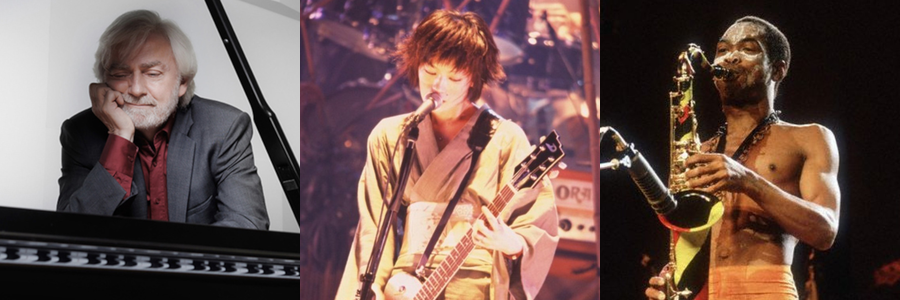

In [11]:
imgs = [
    ".untracked/img/img_woody_guthrie.jpg",
    ".untracked/img/img_simone.jpg",
    ".untracked/img/img_tupac.jpg",
]
out_path = "img/collage_protest.png"

imgs = [
    ".untracked/img/img_zimerman.jpg",
    ".untracked/img/img_shiina.jpg",
    ".untracked/img/img_fela.jpg"
]
out_path = "img/collage_world.png"

collage(imgs, n=1, m=3, w=300, h=300, out_path=out_path, bg_color=(255, 255, 255))